In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
sns.set_context('notebook')
%config InlineBackend.figure_format = 'retina'   # or 'png'
%config InlineBackend.rc = {'figure.dpi': 92}    # force dpi


from utils.setup_environment import *
from utils.Glider1D import Glider1D, CustomStimuli, RenderedData
from utils.glider_utils import *

from flyvis.utils.activity_utils import LayerActivity


ModuleNotFoundError: No module named 'flyvis'

In [2]:
network_view = flyvis.NetworkView(flyvis.results_dir / "flow/0000/000")
network = network_view.init_network()

[2025-12-05 11:41:20] network_view:122 Initialized network view at /home/guardomayas/flyvis_data/results/flow/0000/000
[2025-12-05 11:41:20] logging_utils:23 epe not in /home/guardomayas/flyvis_data/results/flow/0000/000/validation, but 'loss' is. Falling back to 'loss'. You can rerun the ensemble validation to make appropriate recordings of the losses.
[2025-12-05 11:41:25] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.
[2025-12-05 11:41:25] chkpt_utils:36 Recovered network state.


In [3]:
# Load the saved data
fps     = 24
k_size  = 1
x_resol = 33
filename = f'compute_responses/nw_retrained_gliders_{fps}_fps_{x_resol}_pix_{k_size}_ksize.npz'
# filename = f'compute_responses/nw_0_gliders_{fps}_fps_{x_resol}_pix_{k_size}_ksize.npz'

data_loaded = np.load(filename, allow_pickle=True)
responses = data_loaded['responses']
df = pd.DataFrame(data_loaded['df'].item())
print(f"Loaded filename: {filename}")
print(f"Loaded responses shape: {responses.shape}") # seeds, seqs, nframes, neurons

Loaded filename: compute_responses/nw_retrained_gliders_24_fps_33_pix_1_ksize.npz
Loaded responses shape: (6, 20, 300, 45669)


In [4]:
responses_layer = LayerActivity(responses, network.connectome, keepref=True)

In [5]:
df['mean_response'] = np.nan
df['max_response'] = np.nan
df['dsi'] = np.nan # Directional Selectivity Index
df['difference'] = np.nan 
rules = df['rule'].unique()
parities = df['parity'].unique()
df.head()

,sequence_idx,rule,direction,parity,orientation,vel,seed,T,fps,dt,mean_response,max_response,dsi,difference
0,0,uniform_edge,pd,1,x,1,1,72,24,0.01,NaN,NaN,NaN,NaN
1,1,uniform_edge,pd,-1,x,1,1,72,24,0.01,NaN,NaN,NaN,NaN
2,2,uniform_edge,nd,1,x,1,1,72,24,0.01,NaN,NaN,NaN,NaN
3,3,uniform_edge,nd,-1,x,1,1,72,24,0.01,NaN,NaN,NaN,NaN
4,4,2pt,pd,1,x,1,1,72,24,0.01,NaN,NaN,NaN,NaN


Using 451 neurons (excluded 270 edge neurons)


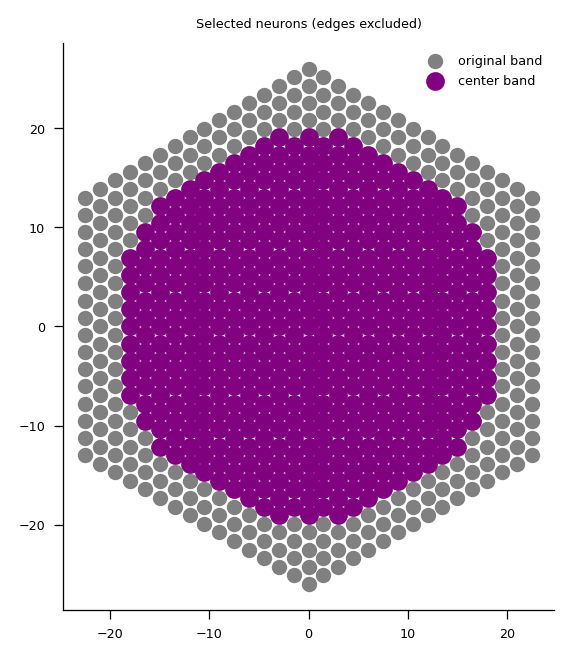

In [6]:
def select_bandindices(y_range_tolerance):
    radius = flyvis.utils.hex_utils.get_hextent(721)

    # Create integer (u, v) and pixel (x, y) coordinates
    u, v = flyvis.utils.hex_utils.get_hex_coords(radius)
    x, y = flyvis.utils.hex_utils.hex_to_pixel(u, v)

    # --- Horizontal band selection ---
    band_indices = np.where(np.abs(y) <= y_range_tolerance)[0]

    # --- Exclude edge neurons (outermost ring) ---
    # Compute each neuron's radial distance from center
    r = np.sqrt(x**2 + y**2)
    max_r = r.max()

    # Define how much of the outer edge to exclude (e.g., 5–10%)
    margin = 0.25 * max_r  # tune this if needed
    valid_indices = np.where(r <= (max_r - margin))[0]

    # Combine both constraints: horizontal band & central region only
    band_indices_center = np.intersect1d(band_indices, valid_indices)

    print(f"Using {len(band_indices_center)} neurons (excluded {len(band_indices) - len(band_indices_center)} edge neurons)")

    # --- Prepare for LEFT-TO-RIGHT coloring for the selected band ---
    u_band = u[band_indices_center]
    min_u = u_band.min()
    max_u = u_band.max()
    range_u = max_u - min_u

    # Visual sanity check (optional)
    fig, ax = plt.subplots(figsize=(4,4))
    ax.scatter(x, y, s=10, color='lightgray', alpha=0.3)
    ax.scatter(x[band_indices], y[band_indices], s=25, color='gray', label='original band')
    ax.scatter(x[band_indices_center], y[band_indices_center], s=40, color='purple', label='center band')
    ax.set_aspect('equal', adjustable='box')
    ax.legend(frameon=False)
    ax.set_title('Selected neurons (edges excluded)')
    plt.show()

    return fig, band_indices_center, u, v, min_u, max_u, x, y
yrange = 26
fig, band_indices_center, u, v, min_u, max_u, x , y = select_bandindices(y_range_tolerance=yrange)


In [7]:
def calcium_nl(V):
    return np.square(np.maximum(0, V))  # R(V)^2
    # return np.porwer(np.maximum(0,V),3)

In [8]:
pre_time = 0.04 # seconds


In [33]:
plotFlag = False
stats_list = []
type1, type2 = "T5a", "T5b"
titlefs = 16
dsilims = (-2, 2)

# normalize
ctype1 = responses_layer[type1]
ctype1 /= np.abs(ctype1).max()
ctype2 = responses_layer[type2]
ctype2 /= np.abs(ctype2).max()

colors = plt.cm.viridis


T = ctype1.shape[2]
t = np.arange(0, T * df['dt'][0], df['dt'][0])
baseline_frames = t < pre_time
num_neurons = ctype1.shape[2]
for seed_idx, seed in enumerate(df['seed'].unique()):
    for rule in rules:
        # if rule == "uniform_edge":
        #     continue
        for parity in parities:
            act_ctype1_R, act_ctype1_L = [], []
            act_ctype2_R, act_ctype2_L = [], []

            right_idx = df.query("rule == @rule and direction == 'pd' and parity == @parity and seed == @seed")['sequence_idx'].item()
            left_idx = df.query("rule == @rule and direction == 'nd' and parity == @parity and seed == @seed")['sequence_idx'].item()
            
            print(f"Processing rule {rule}, parity {parity}, seed {seed} ..., right_idx {right_idx}, left_idx {left_idx}") 

            for neuron in band_indices_center:
                neuron_u_coord = u[neuron]
                # This value will be 1.0 at the center (u=0) and go down to 0.0 at the edges
                # color_val = 1.0 - (np.abs(neuron_u_coord) / max_abs_u)
                range_u = max_u - min_u
                color_val = 1 - (neuron_u_coord - min_u) / range_u
                color = colors(color_val)
                
                c1_resp_R = ctype1[seed_idx,right_idx, :, neuron]
                c1_resp_L = ctype1[seed_idx,left_idx, :, neuron]
                c2_resp_R = ctype2[seed_idx,right_idx, :, neuron]
                c2_resp_L = ctype2[seed_idx,left_idx, :, neuron]

                act_ctype1_R.append(c1_resp_R)
                act_ctype1_L.append(c1_resp_L)
                act_ctype2_R.append(c2_resp_R)
                act_ctype2_L.append(c2_resp_L)

            act_ctype1_R = np.array(act_ctype1_R)
            act_ctype1_L = np.array(act_ctype1_L)
            act_ctype2_R = np.array(act_ctype2_R)
            act_ctype2_L = np.array(act_ctype2_L)

            # assume act_ctype1_R and act_ctype1_L are (n_neurons, n_timepoints)
            baseline_c1 = np.median(np.hstack([act_ctype1_R[:, baseline_frames], act_ctype1_L[:, baseline_frames]]), axis=1, keepdims=True)
            baseline_c2 = np.median(np.hstack([act_ctype2_R[:, baseline_frames], act_ctype2_L[:, baseline_frames]]), axis=1, keepdims=True)

            act_ctype1_R -= baseline_c1
            act_ctype1_L -= baseline_c1
            act_ctype2_R -= baseline_c2
            act_ctype2_L -= baseline_c2

            # act_ctype1_R = calcium_nl(act_ctype1_R)
            # act_ctype1_L = calcium_nl(act_ctype1_L)
            # act_ctype2_R = calcium_nl(act_ctype2_R)
            # act_ctype2_L = calcium_nl(act_ctype2_L)

            global_c1_R = act_ctype1_R.mean()  # mean over space & time
            global_c1_L = act_ctype1_L.mean()
            global_c2_R = act_ctype2_R.mean()
            global_c2_L = act_ctype2_L.mean()

            glob_diff_c1 = global_c1_R - global_c1_L
            glob_diff_c2 = global_c2_R - global_c2_L
            type_diff = glob_diff_c2 -   glob_diff_c1         
            type_ratio = (glob_diff_c2 - glob_diff_c1) / (np.abs(glob_diff_c1) + np.abs(glob_diff_c2) + 1e-9)

            c1_R_mean = act_ctype1_R.mean(axis=1) #mean over time only
            c1_L_mean = act_ctype1_L.mean(axis=1)
            c2_R_mean = act_ctype2_R.mean(axis=1)
            c2_L_mean = act_ctype2_L.mean(axis=1)

            sum_stim_r = act_ctype1_R + act_ctype2_R
            sum_stim_L = act_ctype1_L + act_ctype2_L

            # --- direction selectivity index ---
            eps = 1e-9
            dsi_c1 = (c1_R_mean - c1_L_mean) / np.abs((c1_R_mean + c1_L_mean + eps))
            dsi_c2 = (c2_R_mean - c2_L_mean) / np.abs((c2_R_mean + c2_L_mean + eps))

            stats_list.append({
            "rule": rule,
            "seed": seed,
            "parity": parity,
            "global_c1_R": float(global_c1_R),
            "global_c1_L": float(global_c1_L),
            "global_c2_R": float(global_c2_R),
            "global_c2_L": float(global_c2_L),
            "median_dsi_c1": float(np.median(dsi_c1)),
            "median_dsi_c2": float(np.median(dsi_c2)),
            "mean_dsi_c1": float(np.mean(dsi_c1)),
            "mean_dsi_c2": float(np.mean(dsi_c2)),
            "diff_c1": float(glob_diff_c1),
            "diff_c2": float(glob_diff_c2),
            "type_diff": float(type_diff),
            "type_ratio": float(type_ratio),
            "sum_stim_R": sum_stim_r,
            "sum_stim_L": sum_stim_L
                })
            if plotFlag:
                fig = plt.figure(figsize=(9, 4.2), layout="constrained", dpi=140)
                gs = GridSpec(4, 4, figure=fig, width_ratios=(.8,0.5,.5,.5))
                ax0, ax1 = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])
                ax2, ax3 = fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[3, 0])

                ax4 = fig.add_subplot(gs[0:2, 1])
                ax5 = fig.add_subplot(gs[2:, 1])
                ax6 = fig.add_subplot(gs[1:3,2])
                ax7 = fig.add_subplot(gs[0:2,3])
                ax8 = fig.add_subplot(gs[2:, 3])

                ax0.plot(t, act_ctype1_R.mean(axis=0), c="limegreen", lw=2)
                ax1.plot(t, act_ctype1_L.mean(axis=0), c="limegreen", lw=2)
                ax2.plot(t, act_ctype2_R.mean(axis=0), c="darkgreen", lw=2)
                ax3.plot(t, act_ctype2_L.mean(axis=0), c="darkgreen", lw=2)

                for ax in [ax0, ax1, ax2, ax3]:
                    ax.axvline(pre_time, color='gray', linestyle='--', lw=1)
                    ax.tick_params(axis='both', which='major', labelsize=titlefs)
                    ax.spines['top'].set_visible(False)
                    ax.spines['right'].set_visible(False)

                fig.text(0.45, 0.96, f"{type1}", fontsize=titlefs)
                fig.text(0.45, 0.5, f"{type2}", fontsize=titlefs)

                ax0.set_title(f"{rule}, parity:{parity}, seed {seed} \n--->", fontsize=titlefs-3)
                ax1.set_title(f"<---", fontsize=titlefs-3)
                # _ = ax0.get_ylim()
                # ax1.set_ylim(_)

                ax2.set_title(f"--->", fontsize=titlefs-3)
                ax3.set_title(f"<---", fontsize=titlefs-3)
                # _ = ax2.get_ylim()
                # ax3.set_ylim(_)

                # --- plot summary bars ---
                ax4.bar(["← (Left)", "→ (Right)", "Diff"], [global_c1_L, global_c1_R, glob_diff_c1], color=["gray", "limegreen", "purple"])
                ax5.bar(["← (Left)", "→ (Right)", "Diff"], [global_c2_L, global_c2_R, glob_diff_c2], color=["gray", "darkgreen", "purple"])

                # --- plot DSI distributions ---
                ax6.hist(dsi_c1, bins=np.linspace(dsilims[0], dsilims[1], 20), alpha=0.6, color="limegreen", label=type1)
                ax6.hist(dsi_c2, bins=np.linspace(dsilims[0], dsilims[1], 20), alpha=0.6, color="darkgreen", label=type2)
                ax6.axvline(np.median(dsi_c1), color="limegreen", linestyle="--", lw=2)
                ax6.axvline(np.median(dsi_c2), color="darkgreen", linestyle="--", lw=2)
                # ax6.text(0, 80, f"{np.median(dsi_c1):.2f}")
                # ax6.text(-0.5, 80, f"{np.median(dsi_c2):.2f}")
                ax6.set_xlabel("Direction Selectivity Index")
                ax6.set_ylabel("Count")
                ax6.set_xlim(dsilims[0], dsilims[1])
                ax6.legend(loc="upper right", frameon=False)
                ax6.set_title("Selectivity index \n distribution", fontsize=10)

                # labels
                ax3.set_xlabel('Time (s)')
                ax4.set_ylabel("Mean response (a.u.)", fontsize=10)
                # ax4.set_ylim(-0.0001, 0.0025)
                ax5.set_ylabel("Mean response (a.u.)", fontsize=10)
                ax4.set_title("Activity R-L", fontsize=10)
                ax5.set_title("Activity R-L", fontsize=10)
                # ax5.set_ylim(-0.002, 0.0025)
                
                ax7.set_title("Spatial DSI map", fontsize=10)
                ax7.set_aspect('equal', adjustable='box')

                # Normalize DSI values for color mapping
                vmin, vmax = dsilims
                sc = ax7.scatter(
                    x[band_indices_center], y[band_indices_center],
                    c=dsi_c1, cmap='PiYG', vmin=vmin, vmax=vmax, s=70, edgecolor='k', linewidth=0.2, label=type1
                )
                # plt.colorbar(sc, ax=ax7, fraction=0.046, pad=0.04, label='DSI')

                ax7.scatter(x, y, s=10, color='lightgray', alpha=0.3)  # optional grid context
                ax7.legend(frameon=False)
                ax7.set_xlabel("X coordinate")
                ax7.set_ylabel("Y coordinate")

                ax8.set_title("Spatial DSI map", fontsize=10)
                ax8.set_aspect('equal', adjustable='box')
                sc = ax8.scatter(
                    x[band_indices_center], y[band_indices_center],
                    c=dsi_c2, cmap='PiYG', vmin=vmin, vmax=vmax, s=70, edgecolor='k', linewidth=0.2, label=type2
                )
                # fig.colorbar(sc, ax=ax8, fraction=0.046, pad=0.04, label='DSI')

                ax8.scatter(x, y, s=10, color='lightgray', alpha=0.3)  # optional grid context
                ax8.legend(frameon=False)
                ax8.set_xlabel("X coordinate")
                ax8.set_ylabel("Y coordinate")
                fig.tight_layout()
                plt.show(block=False)


Processing rule uniform_edge, parity 1, seed 1 ..., right_idx 0, left_idx 2
Processing rule uniform_edge, parity -1, seed 1 ..., right_idx 1, left_idx 3
Processing rule 2pt, parity 1, seed 1 ..., right_idx 4, left_idx 6
Processing rule 2pt, parity -1, seed 1 ..., right_idx 5, left_idx 7
Processing rule 3pt_Conv, parity 1, seed 1 ..., right_idx 8, left_idx 10
Processing rule 3pt_Conv, parity -1, seed 1 ..., right_idx 9, left_idx 11
Processing rule 3pt_Div, parity 1, seed 1 ..., right_idx 12, left_idx 14
Processing rule 3pt_Div, parity -1, seed 1 ..., right_idx 13, left_idx 15
Processing rule uncorrelated, parity 1, seed 1 ..., right_idx 16, left_idx 18
Processing rule uncorrelated, parity -1, seed 1 ..., right_idx 17, left_idx 19
Processing rule uniform_edge, parity 1, seed 20 ..., right_idx 0, left_idx 2
Processing rule uniform_edge, parity -1, seed 20 ..., right_idx 1, left_idx 3
Processing rule 2pt, parity 1, seed 20 ..., right_idx 4, left_idx 6
Processing rule 2pt, parity -1, seed 2

In [34]:
basestim    = "2pt +"
basetype    ='diff_c2'
agg         = 'median'
stats_df = pd.DataFrame(stats_list)
results = pd.DataFrame(stats_df[['rule','diff_c1', 'seed', 'diff_c2', 'type_diff']])
parity_map = {1: '+', -1: '-'}
results['rule'] = stats_df['rule'] + ' ' + stats_df['parity'].map(parity_map)
order = ['2pt +', '2pt -', 'uniform_edge +', 'uniform_edge -', '3pt_Div +', '3pt_Div -', '3pt_Conv +', '3pt_Conv -', 'uncorrelated +', 'uncorrelated -']

results['rule'] = pd.Categorical(
        results['rule'],
        categories=order,
        ordered=True,
    )
baseline = results.loc[results["rule"] == basestim, basetype].mean()
# if np.isnan(baseline):
#     baseline = 1.0

type_baseline = results.loc[results["rule"] == basestim, "type_diff"].mean()
# if np.isnan(type_baseline):
#     type_baseline = 1.0
results["diff_c1_norm"] = results["diff_c1"] / baseline
results["diff_c2_norm"] = results["diff_c2"] / baseline
results["type_diff_norm"] = results["type_diff"] / type_baseline
N = len(results['seed'].unique())

# ---------------------------------------------------------
# 4. Aggregation: groupby respects categorical order
# ---------------------------------------------------------
if agg == "mean":
    summary = results.groupby(
        "rule", as_index=False, observed=True
    ).agg({
        "diff_c1_norm": ["mean", "sem"],
        "diff_c2_norm": ["mean", "sem"],
        "type_diff_norm": ["mean", "sem"]
    })
    summary.columns = [
        "rule",
        "diff_c1_center", "diff_c1_err",
        "diff_c2_center", "diff_c2_err",
        "type_diff_center", "type_diff_err"
    ]
    err_label = "SEM"

elif agg == "median":
    def iqr(x): 
        return np.percentile(x, 75) - np.percentile(x, 25)

    summary = results.groupby(
        "rule", as_index=False, observed=True
    ).agg({
        "diff_c1_norm": ["median", iqr],
        "diff_c2_norm": ["median", iqr],
        "type_diff_norm": ["median", iqr]
    })
    summary.columns = [
        "rule",
        "diff_c1_center", "diff_c1_err",
        "diff_c2_center", "diff_c2_err",
        "type_diff_center", "type_diff_err"
    ]
    err_label = "IQR"

# Ensure summary is sorted according to the categorical order
summary["rule"] = pd.Categorical(
    summary["rule"],
    categories=order,
    ordered=True,
)
summary = summary.sort_values("rule").reset_index(drop=True)



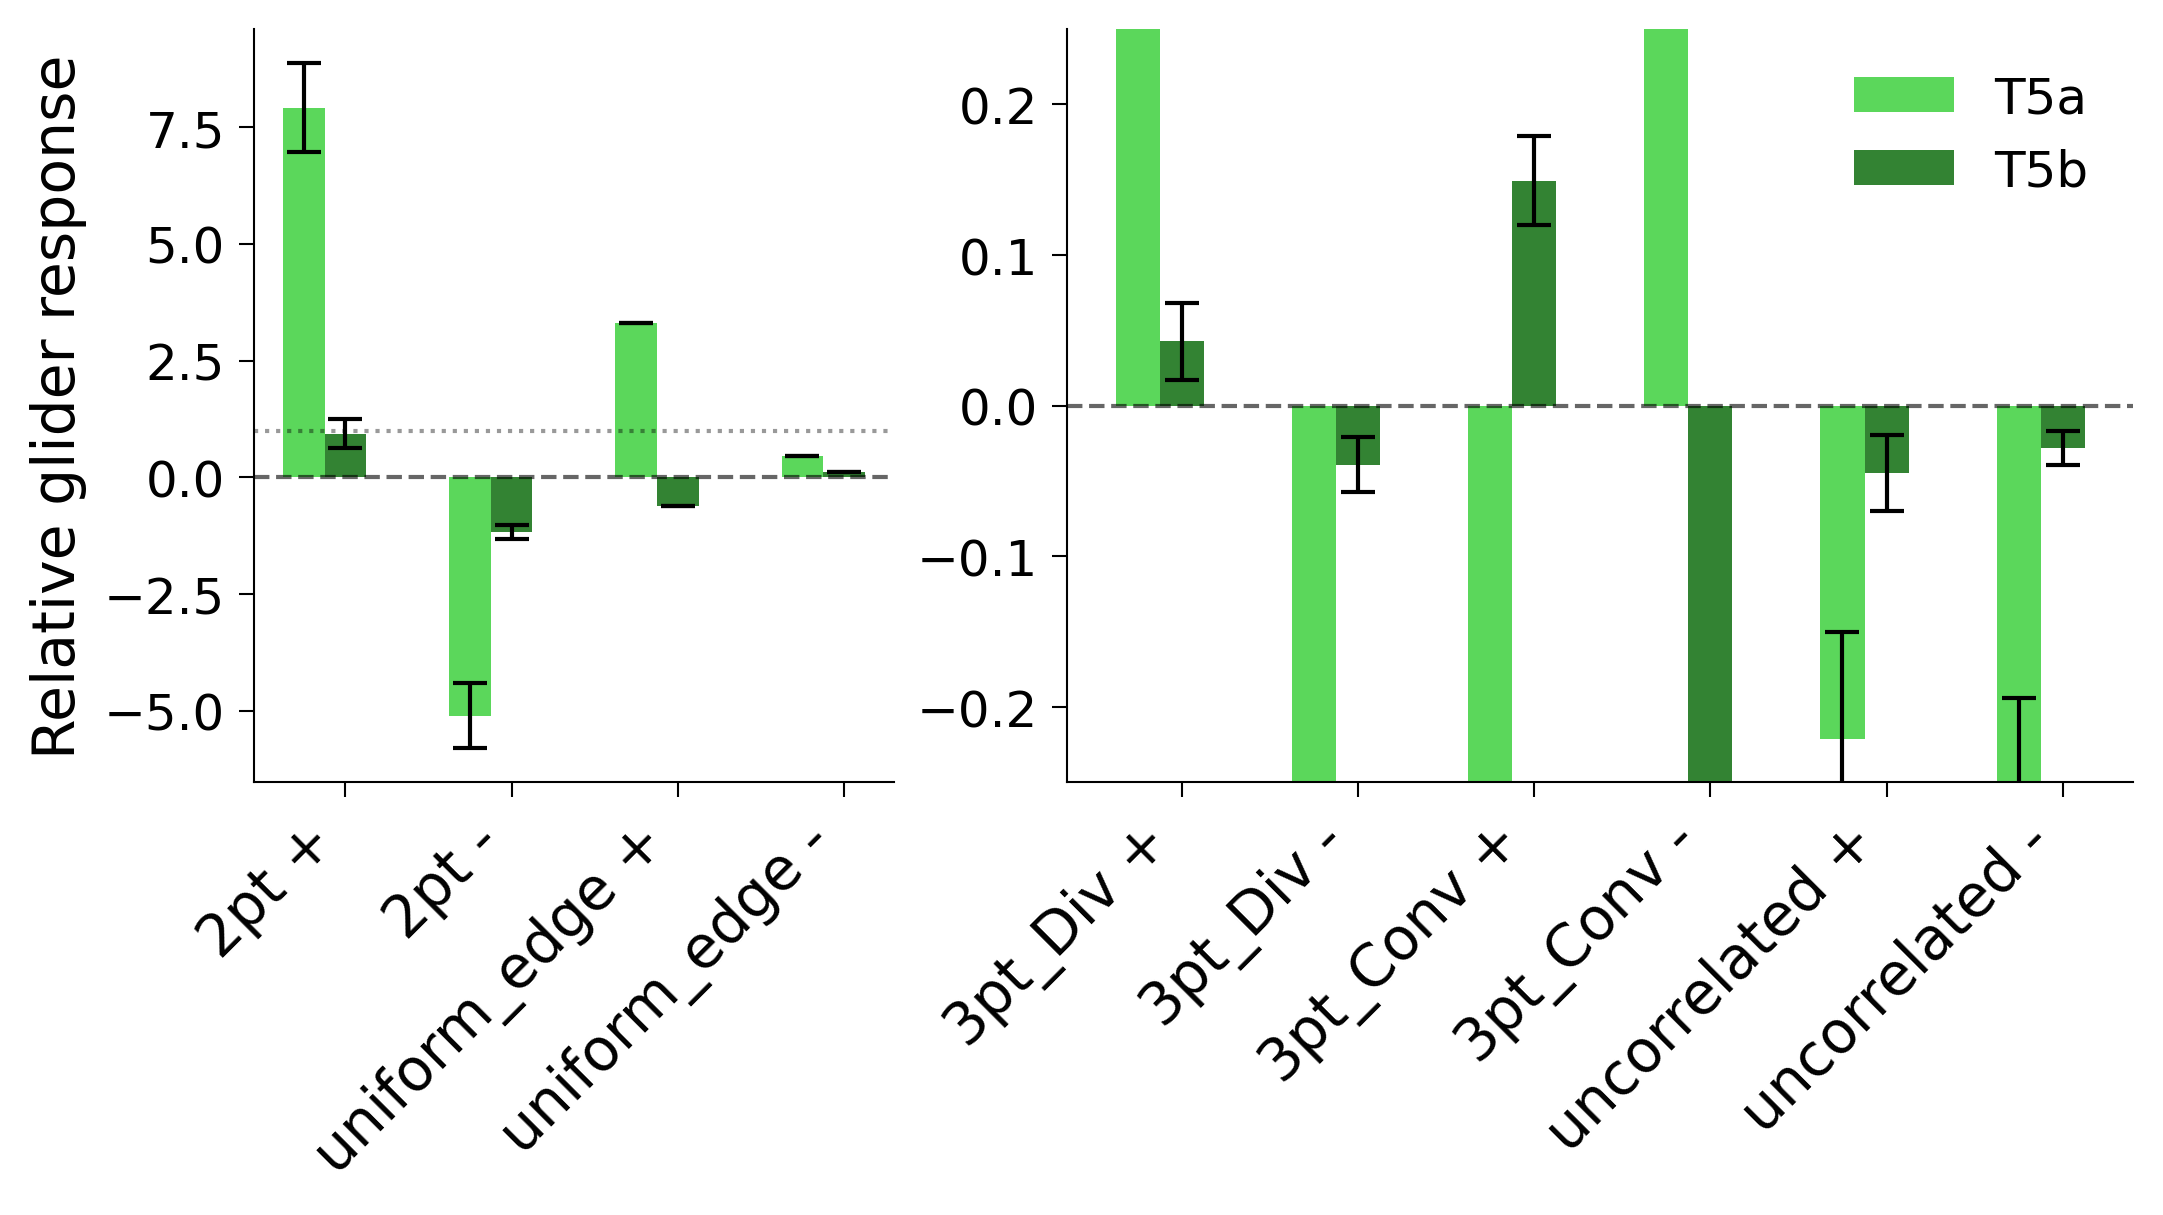

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4), width_ratios=(0.6,1), dpi=150)  # zoomed-in version
fs    = 14
width = 0.25
factor = 1 if agg == "mean" else 2

rules_left = ['2pt +', '2pt -', 'uniform_edge +', 'uniform_edge -']  # example
mask_left  = summary['rule'].isin(rules_left)

summary_left  = summary[mask_left].copy()
summary_right = summary[~mask_left].copy()

# Reindex so x = 0,1,2,... inside each subplot
summary_left  = summary_left.reset_index(drop=True)
summary_right = summary_right.reset_index(drop=True)

# ----------------- LEFT SUBPLOT -----------------
x_left = np.arange(len(summary_left))

axes[0].bar(
    x_left - width,
    summary_left["diff_c1_center"],
    width,
    color="limegreen",
    alpha=0.8,
    label=type1,
)
axes[0].bar(
    x_left,
    summary_left["diff_c2_center"],
    width,
    color="darkgreen",
    alpha=0.8,
    label=type2,
)

for offset, mean_key, err_key, data in [
    (-width, "diff_c1_center", "diff_c1_err", summary_left),
    (0,       "diff_c2_center", "diff_c2_err", summary_left),
]:
    axes[0].errorbar(
        x_left + offset,
        data[mean_key],
        yerr=data[err_key] / factor,
        fmt="none",
        ecolor="k",
        elinewidth=1,
        capsize=4,
        zorder=3,
    )

# ----------------- RIGHT SUBPLOT -----------------
x_right = np.arange(len(summary_right))

axes[1].bar(
    x_right - width,
    summary_right["diff_c1_center"],
    width,
    color="limegreen",
    alpha=0.8,
    label=type1,
)
axes[1].bar(
    x_right,
    summary_right["diff_c2_center"],
    width,
    color="darkgreen",
    alpha=0.8,
    label=type2,
)

for offset, mean_key, err_key, data in [
    (-width, "diff_c1_center", "diff_c1_err", summary_right),
    (0,       "diff_c2_center", "diff_c2_err", summary_right),
]:
    axes[1].errorbar(
        x_right + offset,
        data[mean_key],
        yerr=data[err_key] / factor,
        fmt="none",
        ecolor="k",
        elinewidth=1,
        capsize=4,
        zorder=3,
    )
##Labels & stuff
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=fs-2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axhline(0, color="k", linestyle="--", lw=1, alpha=0.6)
    ax.axhline(1, color="k", linestyle=":",  lw=1, alpha=0.4)

axes[0].set_xticks(x_left)
axes[0].set_xticklabels(summary_left["rule"].astype(str),
                        rotation=45, ha="right", fontsize=fs)
axes[0].set_ylabel("Relative glider response", fontsize=fs)
axes[1].legend(fontsize=fs-2)

axes[1].set_xticks(x_right)
axes[1].set_xticklabels(summary_right["rule"].astype(str),
                        rotation=45, ha="right", fontsize=fs)
axes[1].set_ylim(ymin=-0.25, ymax=.25)

fig.tight_layout()


In [36]:
def plot_summarized_data(stats_df, fps, type1="T4a", type2="T4b", basestim='2pt +', 
                         basetype='diff_c2', agg="mean", annot="stars", inset=False):
    # """
    # Plot summarized data (mean±SEM or median±IQR) with Wilcoxon signed-rank test.
    # Prints which cell types are significant for each condition.
    # """
    # import numpy as np
    # import pandas as pd
    # import matplotlib.pyplot as plt
    # from scipy.stats import wilcoxon

    # stats_df = stats_df.copy()

    # # ---------------------------------------------------------
    # # 1. Build rule_parity and enforce desired order
    # # ---------------------------------------------------------
    # parity_map = {1: '+', -1: '-'}
    # stats_df['rule_parity'] = stats_df['rule'] + ' ' + stats_df['parity'].map(parity_map)

    # order = ['2pt +', '2pt -', '3pt_Div +', '3pt_Div -', '3pt_Conv +', '3pt_Conv -', 'uncorrelated +', 'uncorrelated -', 'uniform_edge +', 'uniform_edge -']
    # stats_df['rule_parity'] = pd.Categorical(
    #     stats_df['rule_parity'],
    #     categories=order,
    #     ordered=True,
    # )

    # ---------------------------------------------------------
    # 2. Baselines (computed before any filtering)
    # ---------------------------------------------------------
    baseline = stats_df.loc[stats_df["rule_parity"] == basestim, basetype].mean()
    if np.isnan(baseline):
        baseline = 1.0

    type_baseline = stats_df.loc[stats_df["rule_parity"] == basestim, "type_diff"].mean()
    if np.isnan(type_baseline):
        type_baseline = 1.0

    stats_df["diff_c1_norm"] = stats_df["diff_c1"] / baseline
    stats_df["diff_c2_norm"] = stats_df["diff_c2"] / baseline
    stats_df["type_diff_norm"] = stats_df["type_diff"] / type_baseline
    N = len(stats_df['seed'].unique())

    # ---------------------------------------------------------
    # 3. Inset filtering (after normalization)
    # ---------------------------------------------------------
    if inset:
        # remove 2pt & uniform_edge from the plotted subset,
        # but baseline was already computed above using full stats_df
        mask = ~stats_df["rule_parity"].astype(str).str.contains("2pt|uniform_edge")
        stats_df = stats_df[mask]
        fig, ax = plt.subplots(figsize=(7, 4), dpi=150)  # zoomed-in version
        ax.set_ylim(-.3, .3)
        ax.set_yticks([-.2, -.1, 0, .1, .2])
        fs = 7
        start_rel = 0.01
    else:
        fs = 10
        fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
        ax.set_ylabel("Relative Response", fontsize=fs)
        start_rel = .15

    # ---------------------------------------------------------
    # 4. Aggregation: groupby respects categorical order
    # ---------------------------------------------------------
    if agg == "mean":
        summary = stats_df.groupby(
            "rule_parity", as_index=False, observed=True
        ).agg({
            "diff_c1_norm": ["mean", "sem"],
            "diff_c2_norm": ["mean", "sem"],
            "type_diff_norm": ["mean", "sem"]
        })
        summary.columns = [
            "rule_parity",
            "diff_c1_center", "diff_c1_err",
            "diff_c2_center", "diff_c2_err",
            "type_diff_center", "type_diff_err"
        ]
        err_label = "SEM"

    elif agg == "median":
        def iqr(x): 
            return np.percentile(x, 75) - np.percentile(x, 25)

        summary = stats_df.groupby(
            "rule_parity", as_index=False, observed=True
        ).agg({
            "diff_c1_norm": ["median", iqr],
            "diff_c2_norm": ["median", iqr],
            "type_diff_norm": ["median", iqr]
        })
        summary.columns = [
            "rule_parity",
            "diff_c1_center", "diff_c1_err",
            "diff_c2_center", "diff_c2_err",
            "type_diff_center", "type_diff_err"
        ]
        err_label = "IQR"

    # Ensure summary is sorted according to the categorical order
    summary["rule_parity"] = pd.Categorical(
        summary["rule_parity"],
        categories=order,
        ordered=True,
    )
    summary = summary.sort_values("rule_parity").reset_index(drop=True)
    print(summary.head())
    # ---------------------------------------------------------
    # 5. Wilcoxon signed-rank tests
    # ---------------------------------------------------------
    pvals = []
    for rp in summary["rule_parity"]:
        subset = stats_df.query("rule_parity == @rp")

        tests = {}
        for key, col in {
            "c1": "diff_c1_norm",
            "c2": "diff_c2_norm",
            "type": "type_diff_norm"
        }.items():
            try:
                stat, p = wilcoxon(subset[col], alternative='two-sided', zero_method='wilcox')
                tests[key] = p
            except ValueError:
                tests[key] = np.nan

        pvals.append(tests)

    pvals = np.array(pvals)

    # ---------------------------------------------------------
    # 6. Pretty-print summary table
    # ---------------------------------------------------------
    def p_to_star(p):
        if np.isnan(p): return "n/a"
        if p < 0.001: return "   ***  "
        elif p < 0.01: return "   **  "
        elif p < 0.05: return "*"
        else: return "ns"

    print(f"\n=== Wilcoxon Signed-Rank Test (vs 0, N = {N} seeds) ===")
    print(f"{'rule_parity':<15}{type1+'(←)':<12}{type2+'(→)':<12}{type2+'−'+type1:<12}")
    print("-" * 51)

    for i, rp in enumerate(summary["rule_parity"]):
        tests = pvals[i]
        stars = {k: p_to_star(v) for k, v in tests.items()}
        print(f"{str(rp):<15}{stars['c1']:<12}{stars['c2']:<12}{stars['type']:<12}")

    # ---------------------------------------------------------
    # 7. Plotting
    # ---------------------------------------------------------
    x = np.arange(len(summary))
    width = 0.25

    ax.bar(x - width, summary["diff_c1_center"], width, color="limegreen", alpha=0.8, label=f"{type1}")
    ax.bar(x,         summary["diff_c2_center"], width, color="darkgreen", alpha=0.8, label=f"{type2}")

    factor = 1 if agg == "mean" else 2
    for offset, mean_key, err_key in [
        (-width, "diff_c1_center", "diff_c1_err"),
        (0, "diff_c2_center", "diff_c2_err"),
    ]:
        ax.errorbar(
            x + offset,
            summary[mean_key],
            yerr=summary[err_key] / factor,
            fmt="none", ecolor="k", elinewidth=1, capsize=4, zorder=3
        )

    # Scatter points
    rng = np.random.default_rng(42)
    for i, rp in enumerate(summary["rule_parity"]):
        subset = stats_df.query("rule_parity == @rp")
        jitter = rng.uniform(-0.07, 0.07, size=len(subset))
        ax.scatter(np.full(len(subset), x[i] - width) + jitter, subset["diff_c1_norm"],
                   color="limegreen", s=25, edgecolor="k", linewidth=0.4, alpha=0.7, zorder=4)
        ax.scatter(np.full(len(subset), x[i]) + jitter, subset["diff_c2_norm"],
                   color="darkgreen", s=25, edgecolor="k", linewidth=0.4, alpha=0.7, zorder=4)

    # Significance annotations
    for i, rp in enumerate(summary["rule_parity"]):
        tests = pvals[i]
        y_max = max(
            summary.loc[i, "diff_c1_center"] + summary.loc[i, "diff_c1_err"] / factor,
            summary.loc[i, "diff_c2_center"] + summary.loc[i, "diff_c2_err"] / factor,
        )
        y_text = y_max + start_rel

        if annot == "stars":
            label = f"{p_to_star(tests['c1'])}  {p_to_star(tests['c2'])}"
        else:
            label = f"p={tests['c1']:.3f}  p={tests['c2']:.3f}  p={tests['type']:.3f}"

        ax.text(x[i] - 0.15, y_text, label, ha="center", va="bottom", fontsize=9)

    # ---------------------------------------------------------
    # 8. Final touches
    # ---------------------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(summary["rule_parity"].astype(str), rotation=45, ha="right", fontsize=fs)
    ax.axhline(0, color="k", linestyle="--", lw=1, alpha=0.6)
    ax.axhline(1, color="k", linestyle=":", lw=1, alpha=0.4)

    if not inset:
        fig.suptitle(
            f"Summarized data for N={N} seeds ({agg.upper()} ± {err_label}). {fps} FPS",
            fontsize=13)
        ax.legend(loc='upper right', frameon=False, fontsize=fs-1)

    plt.tight_layout()
    plt.show()

plot_summarized_data(stats_df, fps=fps, type1=type1, type2=type2, basestim='2pt +', agg='median', inset=True)

KeyError: 'rule_parity'